# AI Customer Churn Prediction System for Banking Customers

## Objective
Predict which customers are likely to leave a bank and identify key factors influencing churn.

## Problem Statement
Customer retention is critical for financial institutions.
This project builds a machine learning model that predicts customer churn probability and provides risk-based retention recommendations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## Dataset Overview

The dataset contains customer demographic, financial and account activity information.

Target Variable:
- Exited = 1 → Customer left
- Exited = 0 → Customer stayed

In [7]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [8]:
df["Exited"].value_counts(normalize=True)*100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

In [9]:
df.groupby("Geography")["Exited"].mean()*100

Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64

In [10]:
df.groupby("IsActiveMember")["Exited"].mean()*100

IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64

In [11]:
df = df.drop(["RowNumber","CustomerId","Surname"],axis=1)

In [12]:
df.groupby("NumOfProducts")["Exited"].mean()*100

NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64

In [13]:
df["AgeGroup"] = pd.cut(df["Age"],
    bins=[18,30,40,50,60,100],
    labels=["18-30","30-40","40-50","50-60","60+"]
)

In [14]:
df.groupby("AgeGroup")["Exited"].mean()*100

C:\Users\Anushka\AppData\Local\Temp\ipykernel_1304\2693275341.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AgeGroup")["Exited"].mean()*100


AgeGroup
18-30     7.502569
30-40    12.087171
40-50    33.965517
50-60    56.210790
60+      24.784483
Name: Exited, dtype: float64

In [15]:
df["CustomerValue"] = (
    df["Balance"] * 0.5 +
    df["EstimatedSalary"] * 0.5
)

In [16]:
df["BalanceSalaryRatio"] = (
    df["Balance"] / (df["EstimatedSalary"] + 1)
)

In [17]:
df["ProductEngagement"] = (
    df["NumOfProducts"] +
    df["HasCrCard"] +
    df["IsActiveMember"]
)

In [18]:
df["RiskScore"] = (
    (df["Age"] > 40).astype(int)
    +
    (df["IsActiveMember"] == 0).astype(int)
    +
    (df["Balance"] == 0).astype(int)
)

In [19]:
df.corr(numeric_only=True)["Exited"].sort_values()

IsActiveMember       -0.156128
ProductEngagement    -0.122148
NumOfProducts        -0.047820
CreditScore          -0.027094
Tenure               -0.014001
HasCrCard            -0.007138
EstimatedSalary       0.012097
BalanceSalaryRatio    0.025963
CustomerValue         0.094755
Balance               0.118533
RiskScore             0.211664
Age                   0.285323
Exited                1.000000
Name: Exited, dtype: float64

In [20]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,CustomerValue,BalanceSalaryRatio,ProductEngagement,RiskScore
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,40-50,50674.440,0.000000,3,2
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,40-50,98175.220,0.744670,2,1
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,40-50,136796.185,1.401362,4,2
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,30-40,46913.315,0.000000,2,2
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,40-50,102297.460,1.587035,3,1


In [21]:
df.drop("AgeGroup", axis=1, inplace=True)

In [22]:
df = pd.get_dummies(
    df,
    columns=["Geography","Gender"],
    drop_first=True
)

In [23]:
X = df.drop("Exited", axis=1)

y = df["Exited"]

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
X_train.shape

(8000, 15)

In [26]:
X_test.shape

(2000, 15)

In [27]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(
    X_train,
    y_train
)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [28]:
y_pred = log_model.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:",
      accuracy_score(y_test,y_pred))

print(classification_report(y_test,y_pred))

Accuracy: 0.808
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1593
           1       0.58      0.21      0.30       407

    accuracy                           0.81      2000
   macro avg       0.70      0.58      0.60      2000
weighted avg       0.78      0.81      0.77      2000



In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
rf_pred = rf_model.predict(X_test)

In [32]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Accuracy: 0.8645
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.79      0.45      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000



In [33]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 2.0 MB/s eta 0:00:35
    --------------------------------------- 1.0/69.5 MB 2.6 MB/s eta 0:00:27
    --------------------------------------- 1.3/69.5 MB 2.6 MB/s eta 0:00:27
   - -------------------------------------- 1.8/69.5 MB 2.2 MB/s eta 0:00:31
   - -------------------------------------- 2.6/69.5 MB 2.5 MB/s eta 0:00:27
   -- ------------------------------------- 3.9/69.5 MB 3.1 MB/s eta 0:00:22
   -- ------------------------------------- 4.7/69.5 MB 3.3 MB/s eta 0:00:20
   --- ------------------------------------ 5.8/69.5 MB 3.4 MB/s eta 0:00:19
   --- ------------------------------------ 6.8/69.5 MB 3.7 MB/s eta 0:00:17
   ---- ----------------------------------- 7.9/69.5 MB 3.8 MB/s eta 0:00:17
   ---- ----

In [34]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

In [35]:
xgb_model.fit(
    X_train,
    y_train
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [36]:
xgb_pred = xgb_model.predict(X_test)

In [37]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:",
      accuracy_score(y_test,xgb_pred))

print(classification_report(y_test,xgb_pred))

Accuracy: 0.8665
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.77      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.76      2000
weighted avg       0.86      0.87      0.85      2000



In [38]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy":[
        accuracy_score(y_test,y_pred),
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,xgb_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.8080
1,Random Forest,0.8645
2,XGBoost,0.8665


In [39]:
from sklearn.metrics import recall_score, f1_score

results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Recall":[
        recall_score(y_test,y_pred),
        recall_score(y_test,rf_pred),
        recall_score(y_test,xgb_pred)
    ],
    "F1 Score":[
        f1_score(y_test,y_pred),
        f1_score(y_test,rf_pred),
        f1_score(y_test,xgb_pred)
    ]
})

results

,Model,Recall,F1 Score
0,Logistic Regression,0.206388,0.304348
1,Random Forest,0.452088,0.575900
2,XGBoost,0.486486,0.597285


In [40]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/2 [slicer]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [47]:
import shap
shap.initjs()

In [48]:
explainer = shap.TreeExplainer(xgb_model)

In [49]:
shap_values = explainer.shap_values(X_test)

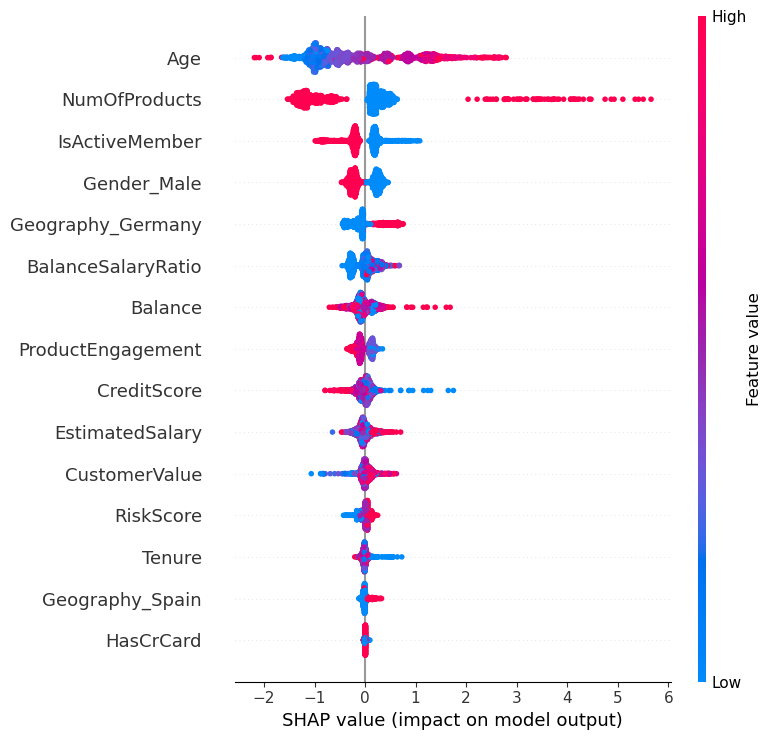

In [50]:
shap.summary_plot(
    shap_values,
    X_test
)

In [51]:
customer = X_test.iloc[0]

In [52]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    customer
)

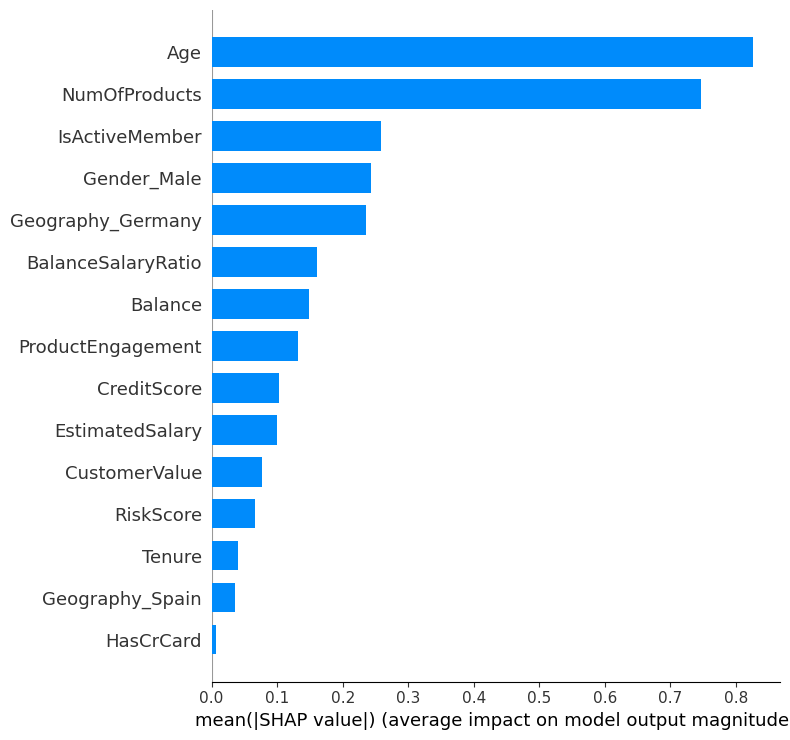

In [55]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

In [53]:
probabilities = xgb_model.predict_proba(X_test)

probabilities[:5]

array([[0.98732895, 0.01267107],
       [0.9229204 , 0.07707959],
       [0.96982104, 0.03017899],
       [0.9337058 , 0.06629422],
       [0.92343503, 0.07656498]], dtype=float32)

In [54]:
risk = xgb_model.predict_proba(X_test)[:,1]

def risk_category(x):
    if x > 0.7:
        return "High Risk"
    elif x > 0.4:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_labels = [risk_category(x) for x in risk]

In [56]:
risk_df = X_test.copy()

risk_df["Churn Probability"] = risk

risk_df["Risk Category"] = risk_labels

risk_df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,CustomerValue,BalanceSalaryRatio,ProductEngagement,RiskScore,Geography_Germany,Geography_Spain,Gender_Male,Churn Probability,Risk Category
5702,585,36,7,0.00,2,1,0,94283.09,47141.545,0.000000,3,2,False,False,True,0.012671,Low Risk
3667,525,33,4,131023.76,2,0,0,55072.93,93048.345,2.379052,2,1,True,False,True,0.077080,Low Risk
1617,557,40,4,0.00,2,0,1,105433.53,52716.765,0.000000,3,1,False,True,False,0.030179,Low Risk
5673,639,34,5,139393.19,2,0,0,33950.08,86671.635,4.105707,2,1,False,True,True,0.066294,Low Risk
4272,640,34,3,77826.80,1,1,1,168544.85,123185.825,0.461754,3,0,False,True,False,0.076565,Low Risk


In [57]:
def recommendation(row):

    if row["Risk Category"] == "High Risk":

        if row["IsActiveMember"] == 0:
            return "Send engagement offer / cashback campaign"

        elif row["Balance"] > 100000:
            return "Assign relationship manager"

        else:
            return "Offer personalized retention benefits"

    elif row["Risk Category"] == "Medium Risk":
        return "Monitor customer activity"

    else:
        return "No action needed"

In [58]:
risk_df["Recommendation"] = risk_df.apply(
    recommendation,
    axis=1
)

# Final Output

The model predicts customer churn probability and classifies customers into risk categories.

Based on risk level, retention strategies are recommended.

In [60]:
risk_df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,CustomerValue,BalanceSalaryRatio,ProductEngagement,RiskScore,Geography_Germany,Geography_Spain,Gender_Male,Churn Probability,Risk Category,Recommendation
5702,585,36,7,0.00,2,1,0,94283.09,47141.545,0.000000,3,2,False,False,True,0.012671,Low Risk,No action needed
3667,525,33,4,131023.76,2,0,0,55072.93,93048.345,2.379052,2,1,True,False,True,0.077080,Low Risk,No action needed
1617,557,40,4,0.00,2,0,1,105433.53,52716.765,0.000000,3,1,False,True,False,0.030179,Low Risk,No action needed
5673,639,34,5,139393.19,2,0,0,33950.08,86671.635,4.105707,2,1,False,True,True,0.066294,Low Risk,No action needed
4272,640,34,3,77826.80,1,1,1,168544.85,123185.825,0.461754,3,0,False,True,False,0.076565,Low Risk,No action needed


In [61]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score

results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred),
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,xgb_pred)
    ],

    "Precision":[
        precision_score(y_test,y_pred),
        precision_score(y_test,rf_pred),
        precision_score(y_test,xgb_pred)
    ],

    "Recall":[
        recall_score(y_test,y_pred),
        recall_score(y_test,rf_pred),
        recall_score(y_test,xgb_pred)
    ],

    "F1 Score":[
        f1_score(y_test,y_pred),
        f1_score(y_test,rf_pred),
        f1_score(y_test,xgb_pred)
    ]
})


results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8080,0.579310,0.206388,0.304348
1,Random Forest,0.8645,0.793103,0.452088,0.575900
2,XGBoost,0.8665,0.773438,0.486486,0.597285


In [63]:
import joblib

joblib.dump(
    xgb_model,
    "customer_churn_xgboost.pkl"
)

['customer_churn_xgboost.pkl']

In [64]:
joblib.dump(
    X_train.columns.tolist(),
    "model_features.pkl"
)

['model_features.pkl']